In [304]:
# Importar librerías
import pandas as pd
import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as st

In [305]:
# Cargar archivos

df_hyp  = pd.read_csv('../datasets/hypotheses_us.csv', sep=';')
df_orders = pd.read_csv('../datasets/orders_us.csv')
df_visits = pd.read_csv('../datasets/visits_us.csv')

In [306]:
# Poner los nombres de las columnas en minusculas.
df_orders.columns = df_orders.columns.str.strip().str.lower()
df_visits.columns = df_visits.columns.str.strip().str.lower()
df_hyp.columns    = df_hyp.columns.str.strip().str.lower()

# Cambiar el tipo de dato a datetime
df_orders['date'] = df_orders['date'].map(lambda x: dt.datetime.strptime(x,'%Y-%m-%d'))
df_visits['date'] = df_visits['date'].map(lambda x: dt.datetime.strptime(x,'%Y-%m-%d'))

# Renombra las columnas
df_orders = df_orders.rename(columns={    
    'transactionid': 'transaction_id',
    'visitorid': 'visitor_id',
    'date': 'date',
    'revenue': 'revenue',
    'group': 'group'})

# Obtener la cantidad de veces que se repite un usuario en cada grupo
cross_user = df_orders.groupby('visitor_id')['group'].nunique().reset_index(name='n_groups')

# Obtener los usuarios que tienen más de un grupo
bad_users = set(cross_user.loc[cross_user['n_groups'] > 1, 'visitor_id'])

# Eliminar las ordenes cuyos usuarios se encuentran en ambos grupos
df_orders = df_orders[~df_orders['visitor_id'].isin(bad_users)]

# Crear el framework ICE
df_hyp['ICE'] = (df_hyp['impact'] * df_hyp['confidence']) / df_hyp['effort']

# Crear el framework RICE
df_hyp['RICE'] = (df_hyp['reach'] * df_hyp['impact'] * df_hyp['confidence']) / df_hyp['effort']

# Imprimir las primeras 3 hipótesis de ICE
print(df_hyp[['hypothesis', 'ICE']].sort_values(by='ICE', ascending=False))

# Imprimir las primeras 3 hipótesis de RICE
print(df_hyp[['hypothesis', 'RICE']].sort_values(by='RICE', ascending=False))

                                          hypothesis        ICE
8  Launch a promotion that gives users discounts ...  16.200000
0  Add two new channels for attracting traffic. T...  13.333333
7  Add a subscription form to all the main pages....  11.200000
6  Show banners with current offers and sales on ...   8.000000
2  Add product recommendation blocks to the store...   7.000000
1  Launch your own delivery service. This will sh...   2.000000
5  Add a customer review page. This will increase...   1.333333
3  Change the category structure. This will incre...   1.125000
4  Change the background color on the main page. ...   1.000000
                                          hypothesis   RICE
7  Add a subscription form to all the main pages....  112.0
2  Add product recommendation blocks to the store...   56.0
0  Add two new channels for attracting traffic. T...   40.0
6  Show banners with current offers and sales on ...   40.0
8  Launch a promotion that gives users discounts ...   16.2


### Interpretación:

Recordemos que el marco ICE está orientado a ponderar las hipótesis más atractivas sin importar a cuántos usuarios afecte; por otro lado, el marco RICE, al considerar el beneficio potencial para los usuarios (Reach) puede alterar la priorización.

A efecto de recomendar las hipótesis más viables para el experimento A/B, el marco RICE provee las mejores métricas, ya que incorpora el parámetro (Reach), mismo que refleja mejor el impacto real en el negocio. 

Las hipótesis a considerar en todo caso serán:
1. Add a subscription form.
2. Add product recommendatio blocks
3. Add two new channels for attracting traffic.
4. Show banners with current offers and sales.

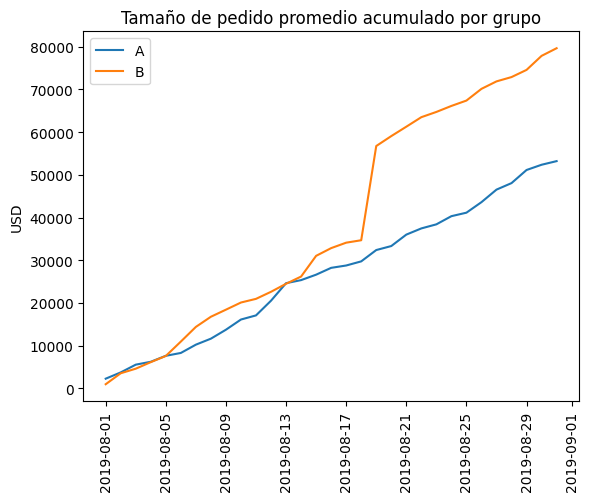

In [307]:
# TEST A/B
# 1.- Ingreso acumulado por grupo

datesGroups = df_orders[['date', 'group']].drop_duplicates()

df_ordersGroup = datesGroups.apply(lambda x: df_orders[np.logical_and(df_orders['date'] <= x['date'], df_orders['group'] == x['group'])].agg({'date':'max', 'group':'max', 'transaction_id':pd.Series.nunique, 'visitor_id':pd.Series.nunique, 'revenue':'sum'}), axis=1).sort_values(by=['date','group'])
df_visitsGroup = datesGroups.apply(lambda x: df_visits[np.logical_and(df_visits['date'] <= x['date'], df_visits['group'] == x['group'])].agg({'date':'max', 'group':'max', 'visits':'sum'}), axis=1).sort_values(by=['date','group'])

# Unir dataframes
df_data = df_ordersGroup.merge(df_visitsGroup, left_on=['date','group'], right_on=['date', 'group'])

# Renombrar columnas
df_data.columns = ['date', 'group', 'orders', 'visitors', 'revenue', 'visits']

# Obtener los dataframes para graficar
df_dataA = df_data[df_data['group'] =='A'][['date','revenue','orders']]
df_dataB = df_data[df_data['group'] =='B'][['date','revenue','orders']]

plt.Figure(figsize=(12,6))
plt.plot(df_dataA['date'], df_dataA['revenue'], label='A')
plt.plot(df_dataB['date'], df_dataB['revenue'], label='B')
plt.title('Tamaño de pedido promedio acumulado por grupo')
plt.xticks(rotation=90)
plt.ylabel('USD')
plt.legend()
plt.show()

### Interpretación:

Ambos grupos muestran crecimiento constante, pero el grupo B supera claramente a A a partir de la mitad del experimento, alrededor del 18-20 de agosto se observa un salto marcado en B (incremento fuerte de ingresos acumulados), lo que genera una brecha sostenida con respecto a A y que puede deberse a una orden atípicamente grande que empuja el acumulado.

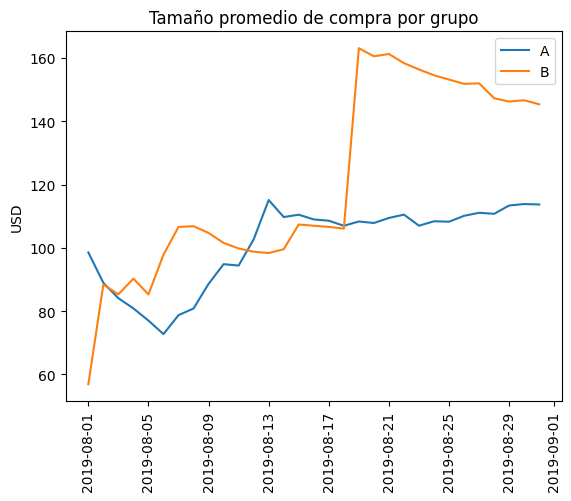

In [308]:
# TEST A/B
# 2.- Tamaño de pedido promedio acumulado por grupo.

plt.title('Tamaño promedio de compra por grupo')
plt.plot(df_dataA['date'], df_dataA['revenue'] / df_dataA['orders'], label='A')
plt.plot(df_dataB['date'], df_dataB['revenue'] / df_dataB['orders'], label='B')
plt.xticks(rotation=90)
plt.ylabel('USD')
plt.legend()

### Interpretación: 

- Grupo A: se mantiene relativamente estable, alrededor de 100–115 USD después de los primeros días, sin grandes fluctuaciones.
- Grupo B: arranca con valores similares, pero a partir del 18 de agosto también da un salto notable, llegando incluso a más de 160 USD. Posteriormente empieza a descender lentamente pero se mantiene siempre por encima de A.
- Conjetura: ese comportamiento refuerza la idea de (valores atípicos) pedidos muy grandes en el grupo B, que dispararon temporalmente los valores. Al acumular más datos, el promedio se estabiliza, aunque siempre se conserva más alto que en A.

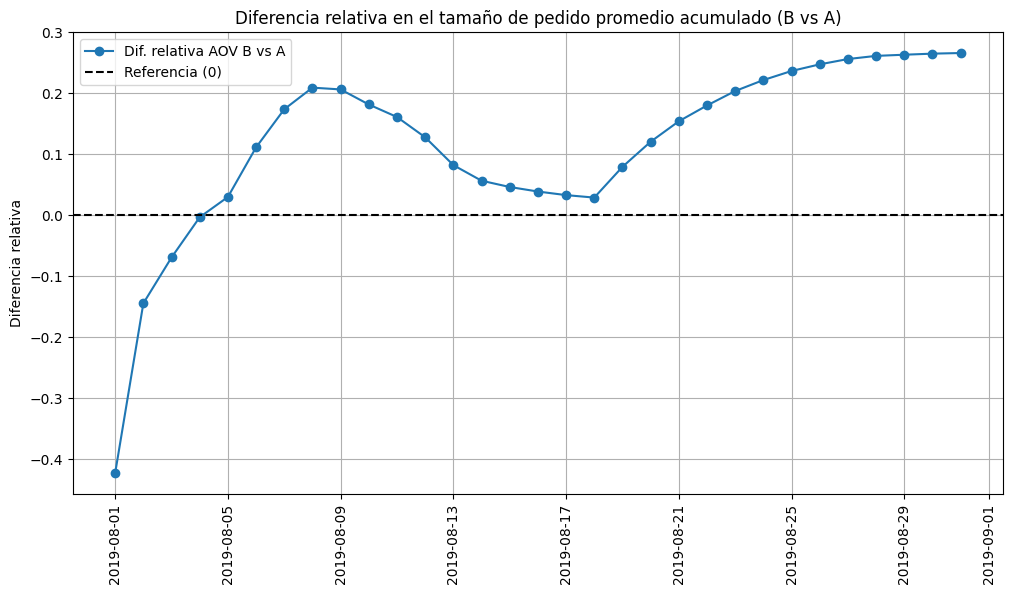

In [309]:
# TEST A/B
# 3.- Representa gráficamente la diferencia relativa en el tamaño de pedido promedio acumulado para el 
#     grupo B en comparación con el grupo A. Elabora conclusiones y conjeturas.

# Obtener el acumulado de ordenes
df_data['cum_orders'] = df_data.groupby('group')['orders'].cumsum()

# Obtener el acumulado de ingresos
df_data['cum_revenue'] = df_data.groupby('group')['revenue'].cumsum()

# Calcular el Average Order Value (AOV) acumulado
df_data['cum_aov'] = df_data['cum_revenue'] / df_data['cum_orders']

# Obtener los dataframes para graficar
df_dataA = df_data[df_data['group'] == 'A'][['date', 'cum_aov']].rename(columns={'cum_aov':'aov_A'})
df_dataB = df_data[df_data['group'] == 'B'][['date', 'cum_aov']].rename(columns={'cum_aov':'aov_B'})

# Unir los dataframes
df_merged = pd.merge(df_dataA, df_dataB, on ='date')

# Obtener la diferencia relativa
df_merged['rel_diff'] = df_merged['aov_B'] / df_merged['aov_A'] - 1

# Graficar
plt.figure(figsize=(12,6))
plt.plot(df_merged['date'], df_merged['rel_diff'], marker='o', label='Dif. relativa AOV B vs A')
plt.axhline(y=0, color='black', linestyle='--', label='Referencia (0)')
plt.title('Diferencia relativa en el tamaño de pedido promedio acumulado (B vs A)')
plt.xticks(rotation=90)
plt.ylabel('Diferencia relativa')
plt.legend()
plt.grid(True)
plt.show()

### Interpretación: 

- El grupo B termina consistentemente con un ticket promedio acumulado más alto que A (≈ +25%).
- La variabilidad inicial se debe al bajo número de observaciones; hacia el cierre, la diferencia se mantiene estable, lo que refuerza su validez.
- Esto sugiere que la variante B no solo genera más ingresos acumulados, sino que también los pedidos promedio son más grandes.
- El hecho de que la curva no regrese a cero ni se cruce de nuevo con A al final indica que la diferencia no se debe al azar, aunque conviene confirmarla con la prueba "U" de Mann–Whitney.

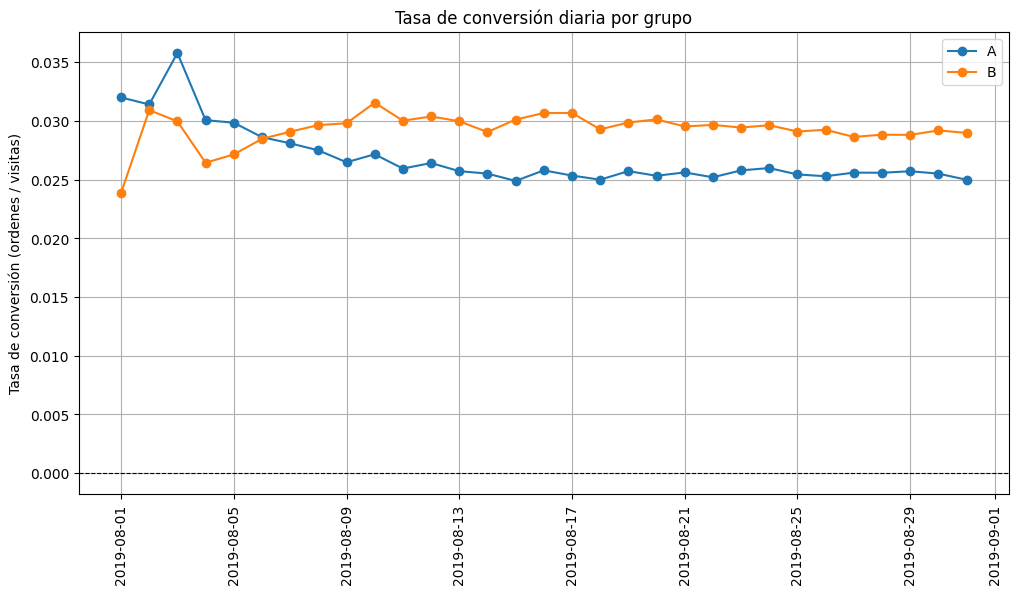

In [310]:
# TEST A/B
# 4.- Calcula la tasa de conversión de cada grupo como la relación entre los pedidos y el número de visitas de cada día. 
#     Representa gráficamente las tasas de conversión diarias de los dos grupos y describe la diferencia. Saca conclusiones y haz conjeturas.

# Obtener la tasa de conversión diaria
df_data['conversion'] = df_data['orders'] / df_data['visits']

# Obtener los dataframes para graficar
df_dataA = df_data[df_data['group'] == 'A'][['date', 'conversion']]
df_dataB = df_data[df_data['group'] == 'B'][['date', 'conversion']]

# 3. Graficar
plt.figure(figsize=(12,6))
plt.plot(df_dataA['date'], df_dataA['conversion'], marker='o', label='A')
plt.plot(df_dataB['date'], df_dataB['conversion'], marker='o', label='B')
plt.title('Tasa de conversión diaria por grupo')
plt.xticks(rotation=90)
plt.ylabel('Tasa de conversión (ordenes / visitas)')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.legend()
plt.grid(True)
plt.show()

### Interpretación:

- El grupo A inicia con una conversión alta y el grupo B con una conversión baja; conforme pasa el tiempo, las tendencias se invierten y posteriormente cambian para estabilizarse. 
- La diferencia observada es constante y consistente, lo cual es indicativo que no se trata de una situación aleatoria, sino el efecto de la aplicación de medidas o cambios en el grupo B.
- Dicho cambio probablemente reduce fricciones en el embudo de compra o motiva a mas visitantes a realizar pedidos. 
- El hecho de que B también tenga un tamaño de orden promedio mayor, produce la hipótesis de que B no solo logra más compradores, sino que además gastan más por pedido.
- La combinación de mayor conversión y mayor orden promedio en el grupo B sugiere que es mejor que el grupo A desde el punto de vista de negocio.
- Hasta este punto, el grupo B ha demostrado ser mejor en las métricas claves de conversión y tamaño de orden.

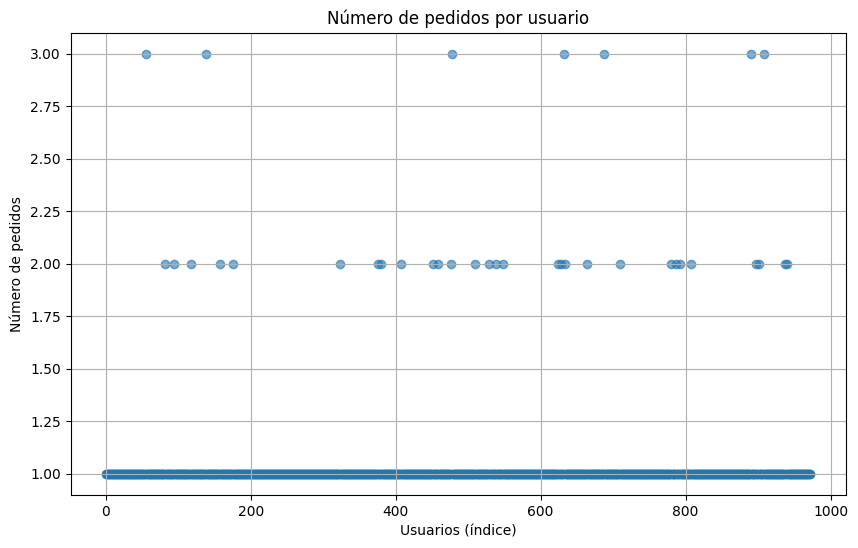

In [311]:
# TEST A/B
# 5.- Traza un gráfico de dispersión del número de pedidos por usuario. Elabora conclusiones y conjeturas.

# Obtener las ordenes por usuario
df_obu = df_orders.groupby('visitor_id')['transaction_id'].nunique().reset_index()

# 3. Gráfico de dispersión
plt.figure(figsize=(10,6))
plt.scatter(range(len(df_obu)), df_obu['transaction_id'], alpha=0.6)
plt.title('Número de pedidos por usuario')
plt.xlabel('Usuarios (índice)')
plt.ylabel('Número de pedidos')
plt.grid(True)
plt.show()

### Interpretación:

- La gran mayoría de los usuarios hicieron solo un pedido, la base es mayormente compradores únicos.
- Los usuarios con 2 pedidos es un grupo recurrente pero pequeño.
- En casos excepcionales se realizan 3 pedidos.
- No hay pedidos de más de 3 artículos.

Si el objetivo es aumentar los ingresos, no basta con captar usuarios nuevos, es imperante diseñar programas de lealtad, descuentos para segunda compra o re-marketing que incentiven a los usuarios a comprar nuevamente. 

In [312]:
# TEST A/B
# 6.- Calcula los percentiles 95 y 99 del número de pedidos por usuario. 
#     Define el punto en el cual un punto de datos se convierte en una anomalía.

print('Perecentiles 95/99:', np.percentile(df_obu['transaction_id'], [95, 99]))
print('Los usuarios con 3 o más pedidos se consideran anómalos.')

Perecentiles 95/99: [1. 2.]
Los usuarios con 3 o más pedidos se consideran anómalos.


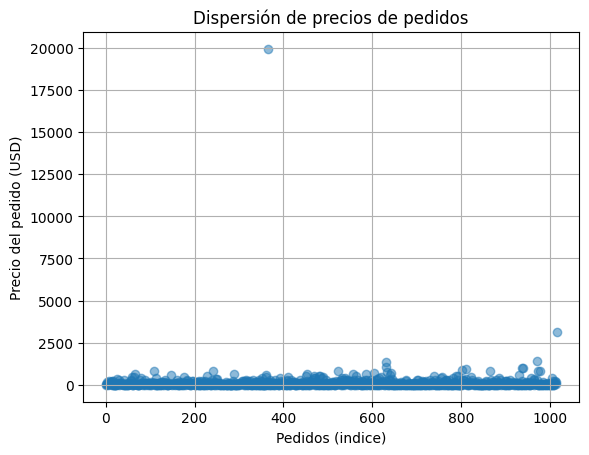

In [313]:
# TEST A/B
# 7.- Traza un gráfico de dispersión de los precios de los pedidos. Haz conclusiones y conjeturas.

plt.Figure(figsize=(10,6))
plt.scatter(range(len(df_orders)), df_orders['revenue'], alpha=0.5)
plt.title('Dispersión de precios de pedidos')
plt.xlabel('Pedidos (indice)')
plt.ylabel('Precio del pedido (USD)')
plt.grid(True)
plt.show()

### Interpretación:

- La gran mayoría de los pedidos están agrupados en un rango bajo (entre $0 y $500), lo que sugiere un comportamiento típico de compras moderadas y relativamente homogéneas.
- Se detectan valores atípicos que pueden alterar las métricas de futuros análisis. 

### Conjeturas:
- Los valores atípicos puede que provengan de errores en la carga de datos o clientes corporativos que realizan compras elevadas.
- La limpieza de estos valores otorgará un panorama más realista y consistente del tamaño promedio de pedido para el cliente común.

In [314]:
# TEST A/B
# 8.- Calcula los percentiles 95 y 99 de los precios de los pedidos. 
#     Define el punto en el cual un punto de datos se convierte en una anomalía.

print('Perecentiles 95 - 99:', np.percentile(df_orders['revenue'], [95, 99]))
print('Los pedidos mayores a $830 se consideran anómalos.')

Perecentiles 95 - 99: [414.275 830.3  ]
Los pedidos mayores a $830 se consideran anómalos.


In [315]:
# 9.- Encuentra la significancia estadística de la diferencia en la conversión entre los grupos 
#     utilizando los datos EN BRUTO. Elabora tus conclusiones y conjeturas. 

# Obtener el número de pedidos por usuario y cada grupo.
df_obuA = df_orders[df_orders['group'] == 'A'].groupby('visitor_id', as_index=False).agg({'transaction_id':pd.Series.nunique})
df_obuB = df_orders[df_orders['group'] == 'B'].groupby('visitor_id', as_index=False).agg({'transaction_id':pd.Series.nunique})

# Cambiar los nombres de las columnas
df_obuA.columns = ['visitor_id', 'orders']
df_obuB.columns = ['visitor_id', 'orders']

# Construcción de la muestra
df_sampleA = pd.concat([df_obuA['orders'], pd.Series(0, index=np.arange(df_visits[df_visits['group'] == 'A']['visits'].sum() - len(df_obuA['orders'])),name='orders')], axis=0)
df_sampleB = pd.concat([df_obuA['orders'], pd.Series(0, index=np.arange(df_visits[df_visits['group'] == 'B']['visits'].sum() - len(df_obuB['orders'])),name='orders')], axis=0)

# Obtener el valor-p y la diferencia relativa
p_value = st.mannwhitneyu(df_sampleA, df_sampleB)[1]
diff_rel = df_sampleB.mean() / df_sampleA.mean() - 1

# Impresión de resultados 
print('Valor-p: {0:.3f}'.format(p_value))
print('Diferencia relativa: {0:.3f}'.format(diff_rel))

Valor-p: 0.938
Diferencia relativa: -0.005


### Interpretación:

- El valor-p (0.938) es muy alto, lo que significa que no podemos rechazar H0, es decir, no hay evidencia estadísticamente significativa de diferencia en el número de pedidos por usuario entre A y B.
- El grupo B tuvo ligeramente menos pedidos en promedio que el grupo A, pero la diferencia es mínima y es estadísticamente irrelevante, ya que el valor-p es muy grande.

### Conjeturas:
- Ambos grupos se comportan prácticamente igual en pedidos por usuario.
- No hay diferencia estadística, la variación es meramente ruido.


In [316]:
# 10. - Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido 
#       entre los grupos utiliznado los datos en bruto. Haz conclusiones y conjeturas 

p_value = st.mannwhitneyu(df_orders[df_orders['group'] == 'A']['revenue'], df_orders[df_orders['group'] == 'B']['revenue'])[1]
diff_rel = df_orders[df_orders['group'] =='B']['revenue'].mean() / df_orders[df_orders['group'] =='A']['revenue'].mean() - 1

print('Valor-p: {0:.3f}'.format(p_value)) 
print('Diferencia relativa: {0:.3f}'.format(diff_rel))

Valor-p: 0.862
Diferencia relativa: 0.278


### Interpretación:
- El valor-p (0.862) es muy alto, por lo que no podemos rechazar la hipótesis nula; no hay evidencia estadística de que el tamaño promedio de los pedidos entre los grupos A y B sea diferente.
- Aunque el grupo B muestra pedidos promedio más grandes, el resultado no es estadísticamente significativo. Esto representa que esa diferencia se debe al azar y no necesariamente a un efecto real de la prueba.
- Dado que estamos trabajando con datos en bruto, es muy probable que los valores atípicos (pedidos altos) estén influyendo en la media y generando la ilusión de una diferencia grande, anque no sea consistente en la muestra.

### Conjeturas:
- El grupo B no muestra un efecto real en el tamaño promedio de los pedidos frente al grupo A.
- La variabilidad en los datos es alta; aunque en promedio B está por encima, esa diferencia no se sostiene de forma estadística. 

In [317]:
# 11.-  Encuentra la significancia estadística de la diferencia en la conversión entre los grupos 
#       utilizando los datos FILTRADOS. Elabora tus conclusiones y conjeturas. 
#       Se considerarán anómalos: 
#       Usuarios con más de 3 pedidos y pedidos mayores a $830 

# Obtener los usuarios con más de 2 ordenes
df_Users_With_Many_Orders = pd.concat([df_obuA[df_obuA['orders'] > 2]['visitor_id'], df_obuB[df_obuB['orders'] > 2]['visitor_id']], axis=0)

# Obtener los usuarios con ordenes mayores a $830 USD
df_Users_With_Expensive_Orders = df_orders[df_orders['revenue'] > 830]['visitor_id']

# Unir los usuarios anormales en un solo dataframe
df_abnormal_users = pd.concat([df_Users_With_Many_Orders, df_Users_With_Expensive_Orders], axis=0).drop_duplicates().sort_values()

# Crear nuevos dataframes con la información filtrada
df_sampleAFiltered = pd.concat([df_obuA[np.logical_not(df_obuA['visitor_id'].isin(df_abnormal_users))]['orders'], pd.Series(0, index=np.arange(df_visits[df_visits['group']=='A']['visits'].sum() - len(df_obuA['orders'])), name='orders')], axis=0)
df_sampleBFiltered = pd.concat([df_obuB[np.logical_not(df_obuB['visitor_id'].isin(df_abnormal_users))]['orders'], pd.Series(0, index=np.arange(df_visits[df_visits['group']=='B']['visits'].sum() - len(df_obuB['orders'])), name='orders')], axis=0)

# Obtener el valor-p y la diferencia relativa
p_value = st.mannwhitneyu(df_sampleAFiltered, df_sampleBFiltered)[1]
diff_rel = df_sampleBFiltered.mean() / df_sampleAFiltered.mean() - 1

# Imprimir resultados 
print('Valor-p: {0:.5f}'.format(p_value))
print('Diferencia relativa: {0:.3f} '.format(diff_rel))

Valor-p: 0.00629
Diferencia relativa: 0.192 


### Interpretación:

- El valor-p es menor a 0.05, por lo que existen diferencias estadisticas significativas en la conversión entre los grupos A y B , una vez eliminados los usuarios anómalos. 
- El grupo B tiene una mejor conversión promedio (19% mayor)
- El proceso de filtrado de datos alteró los resultados, anteriormente parecía que los grupos eran iguales, sin embargo, después de eliminar las anomalías, se hace evidente que el grupo B convierte mejor que el grupo A de forma significativa.
- El cambio aplicado a los usuarios del grupo B tuvo un impacto positivo y real sobre la conversión.
- El aumento del 19% en la tasa de conversión no solo es estadísticamente significativo, sino también relevante en términos de negocio.

### Conjeturas:
- Los usuarios detectados como anómalos (muchos pedidos o importes altos) estaban generando ruido en el análisis, ocultando el efecto real.
- Al limpiar los datos, se observa que B atrae más compradores únicos o mejora el embudo de conversión.



In [318]:
# 12.-  Encuentra la significancia estadística de la diferencia en el tamaño promedio de pedido
#       entre los grupos utilizando los datos FILTRADOS. Haz conclusiones y conjeturas

# Obtener el dataframe filtrado
df_orders_filtered = df_orders[np.logical_not(df_orders['visitor_id'].isin(df_abnormal_users))]

# Obtener el valor-p y la diferencia relativa
p_value = st.mannwhitneyu(df_orders_filtered[df_orders_filtered['group']=='A']['revenue'], df_orders_filtered[df_orders_filtered['group']=='B']['revenue'])[1]
diff_rel = df_orders_filtered[df_orders_filtered['group']=='B']['revenue'].mean() / df_orders_filtered[df_orders_filtered['group']=='A']['revenue'].mean() - 1

print('Valor-p (filtrado): {0:.5f}'.format(p_value))
print('Diferencia relativa (filtrado): {0:.3f}'.format(diff_rel))

Valor-p (filtrado): 0.87671
Diferencia relativa (filtrado): -0.014


### Interpretación:

- El valor-p es muy superior a alpha 0.05, por lo que no hay evidencia estadística  de diferencia significativa entre los tamaños promedio de los pedidos de los grupos A y B despues del filtrado; el valor-p alto es indicativo de que las diferencias observadas se deben al azar. 
- La diferencia relativa (-1.4%) refuerza que los grupos son muy similares en el tamaño promedio de la orden. 

### Conjeturas:
- El tamaño de orden promedio no se ve impactado por el cambio introducido en el grupo B, por lo que el foco del análisis debe estar más en la conversión y no tanto en el tamaño de la orden. 
- Se observa que el cambio introducido tiene mejor impacto en la tasa de conversión, lo que motiva a los clientes a comprar más (más cantidad de ordenes de precio similar).

## Conclusiones generales:

1. Conversión (Conversion Rate):
    - Valor-p bajo (0.007 en filtrados).
    - Diferencia relativa +19% a favor del grupo B.
    - Conclusión rápida: existe evidencia estadística fuerte de que el grupo B convierte más que el grupo A.

2. Tamaño promedio del pedido (Average Order Value - AOV):
    - Valor-p alto (0.87 en filtrados).
    - Diferencia relativa -1.4% (prácticamente nula).
    - Conclusión rápida: no hay evidencia de diferencias significativas en el tamaño promedio entre los grupos.

3. Ingresos acumulados y estabilidad:
    - El grupo B muestra un mejor desempeño en ingresos gracias a mayor conversión, aunque la orden promedio se mantuvo igual.
    - Tras filtrar datos, los resultados siguen siendo consistentes.

## Decisión recomendada:
- En base a los resultados obtenidos, la decisión se decante por parar la prueba y considerar al grupo B como líder.
- La diferencia en conversión es estadísticamente significativa y consistente incluso despues de filtrar las anomalías.
- El tamaño de la orden no cambia, por lo que el incremento en ingresos vendrá por un mayor volumen de compradores, lo cual es viable y escalable.
- Continuar la prueba no aportará valor extra, ya que no tenemos significancia en la métrica más crítica.